In [119]:
import torch

In [120]:
SEQ_LEN = 24
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001
Q_VAL = 0.95

DATA_PATH = "dataset/final.csv"
TEST_PATH = "dataset/final.csv"
MODEL_SAVE_PATH = f"models/spike_aware_q{int(Q_VAL*100)}_seq{SEQ_LEN}.pth40"
SCALER_SAVE_PATH = f"scalers/feature_scaler_seq{SEQ_LEN}.pkl"
print(MODEL_SAVE_PATH)
print(SCALER_SAVE_PATH)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

FEATURES = [
    "ALLSKY_SFC_SW_DIFF", "ALLSKY_SFC_SW_DNI", "TOA_SW_DWN",
    "RH2M", "QV2M", "PS", "WS2M", "CLOUD_AMT",
    "ALLSKY_SFC_LW_DWN", "T2M", "hour_sin", "hour_cos", "month_sin", "month_cos"
]

models/spike_aware_q95_seq24.pth40
scalers/feature_scaler_seq24.pkl


In [121]:
from models_code.model_5 import SpikeAwareHybrid
import joblib

In [122]:
model = SpikeAwareHybrid(len(FEATURES))

In [123]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

C:\Users\grins\AppData\Local\Temp\ipykernel_23264\1149205557.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_SAVE_PATH))


<All keys matched successfully>

In [124]:
model.to(device=DEVICE)

SpikeAwareHybrid(
  (cnn_small): Conv1d(14, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (cnn_med): Conv1d(14, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (cnn_dil): Conv1d(14, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
  (bn): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (lstm): LSTM(384, 256, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [125]:
scaler = joblib.load(SCALER_SAVE_PATH)

In [126]:
input_tensor = torch.tensor([
    [-1.10274237, -1.11460157, -0.95646443,  1.30506515,  1.17918018,  0.69877117, 0.45676455,  1.35236753,  0.82479001,  0.09102185,  1.2859083,   1.86203596, -1.0777995,  -1.41563835],
    [-0.4564535,  -1.124114,   -0.18174588,  1.10088614,  1.19652318,  0.70767264, 0.9707408,   1.37516746,  0.92606053,  0.24183154,  1.23723646,  1.08836603, -1.0777995,  -1.41563835],
    [ 0.32921992, -1.13242327,  0.49789121,  0.78688974,  1.15489997,  0.71212338, 1.67745816,  1.37993954,  1.04777443,  0.44147483,  1.09453785,  0.36742042, -1.0777995,  -1.41563835],
    [ 0.70643352, -1.13242327,  1.03607835,  0.52251453,  1.13755697,  0.7106398,  1.95586196,  1.37993954,  1.18160295,  0.64111813,  0.86753714, -0.2516696,  -1.0777995,  -1.41563835],
    [ 1.6469264,  -1.12437719,  1.39608542,  0.35250093,  1.13061977,  0.7032219,  2.00583188,  1.37993954,  1.28533424,  0.78331011,  0.57170406, -0.72671408, -1.0777995,  -1.41563835],
    [ 1.34669901, -1.13137051,  1.55342571,  0.25854605,  1.12368257,  0.6898697,  1.99869332,  1.37993954,  1.31940656,  0.86230566,  0.22719914, -1.02533953, -1.0777995,  -1.41563835],
    [ 1.71374817, -1.12482837,  1.49721042,  0.22316044,  1.11501106,  0.67503391, 1.97013908,  1.37993954,  1.37051504,  0.88672247, -0.14250018, -1.12719511, -1.0777995,  -1.41563835],
    [ 1.00562564, -0.69391169,  1.23139912,  0.21787294,  1.11847966,  0.66316528, 1.88447637,  1.37993954,  1.42881657,  0.8924676,  -0.5121995,  -1.02533953, -1.0777995,  -1.41563835],
    [ 0.80770144, -1.00120443,  0.7739661,   0.24227681,  1.13755697,  0.65574739, 1.71315095,  1.37993954,  1.42957374,  0.88241362, -0.85670442, -0.72671408, -1.0777995,  -1.41563835],
    [ 0.59547174, -0.9508224,   0.15604079,  0.34273938,  1.19999178,  0.65574739, 1.33480732,  1.36323727,  1.35158598,  0.83501629, -1.15253751, -0.2516696,  -1.0777995,  -1.41563835],
    [-0.43433644, -1.0883202,  -0.58022838,  0.58596458,  1.31445561,  0.6616817,  0.68519844,  1.35289776,  1.27113744,  0.70718713, -1.37953822,  0.36742042, -1.0777995,  -1.41563835],
    [-1.21822168, -1.12855062, -1.3810227,   0.88938597,  1.35954742,  0.67355033, 0.07842091,  1.34998149,  1.10361518,  0.50179871, -1.52223683,  1.08836603, -1.0777995,  -1.41563835],
    [-1.48042654, -1.13242327, -1.71724638,  1.33556998,  1.04737335,  0.70618906, 0.42107175,  1.3621768,   0.77103146, -0.02244448,  1.23723646,  2.63570589, -1.0777995,  -1.41563835],
    [-0.81343234, -1.05816619, -0.95841816,  1.20297564,  1.09073086,  0.71954127, 0.78513827,  1.28767935,  0.77141004,  0.09820327,  1.2859083,   1.86203596, -1.0777995,  -1.41563835],
    [-0.0766988,  -0.96646339, -0.18239712,  0.92802543,  1.10460526,  0.7314099,  1.37050011,  1.2919212,   0.90864578,  0.30215541,  1.23723646,  1.08836603, -1.0777995,  -1.41563835],
    [ 0.90266365, -0.91344947,  0.49828196,  0.54203762,  1.05951345,  0.73586063, 2.03438611,  1.27018173,  1.06764996,  0.57074028,  1.09453785,  0.36742042, -1.0777995,  -1.41563835],
    [ 1.44514348, -0.48114165,  1.03725058,  0.27562875,  1.04737335,  0.73437705, 2.04866323,  1.17474015,  1.18349585,  0.79623666,  0.86753714, -0.2516696,  -1.0777995,  -1.41563835],
    [ 1.63440908, -0.43474507,  1.3976484,   0.13205268,  1.06471635,  0.72695916, 1.79881366,  1.0336987,   1.32092089,  0.94561006,  0.57170406, -0.72671408, -1.0777995,  -1.41563835],
    [ 2.29462699, -0.28453897,  1.55498869,  0.04419876,  1.08726226,  0.71360695, 1.52040986,  1.34812568,  1.34874662,  1.04902241,  0.22719914, -1.02533953, -1.0777995,  -1.41563835],
    [ 2.37697777, -0.78200503,  1.49840871, -0.00989647,  1.09766806,  0.69580401, 1.25628317,  1.37993954,  1.49450044,  1.11078257, -0.14250018, -1.12719511, -1.0777995,  -1.41563835],
    [ 2.26432191, -0.98932329,  1.23176381, -0.04202823,  1.09246516,  0.68096823, 1.03498783,  1.37993954,  1.48257513,  1.13807194, -0.5121995,  -1.02533953, -1.0777995,  -1.41563835],
    [ 1.46434297, -0.93736213,  0.77331486, -0.04894266,  1.09073086,  0.67058318, 0.8493853,   1.3621768,   1.50680433,  1.14238079, -0.85670442, -0.72671408, -1.0777995,  -1.41563835],
    [ 0.89296978, -0.996843,    0.15403496,  0.05924781,  1.17224298,  0.6690996,  0.42821031,  1.35713961,  1.46194244,  1.09067461, -1.15253751, -0.2516696,  -1.0777995,  -1.41563835],
    [-0.25674112, -1.05884296, -0.58369299,  0.19957004,  1.23120919,  0.67651749,-0.05007315,  1.30968394,  1.39228347,  0.99587995, -1.37953822,  0.36742042, -1.0777995,  -1.41563835]
], dtype=torch.float32, device='cuda') 
input_tensor = input_tensor.unsqueeze(0)  

In [127]:
import numpy as np

In [128]:
%%time
model.eval()
with torch.no_grad():
    print(np.expm1(model(input_tensor).cpu().numpy()))

[[56.947803]]
CPU times: total: 31.2 ms
Wall time: 34.3 ms


📊 Benchmark Results:
  Average Latency: 5.07 ms per request
  Throughput: 197.21 QPS
  Device: cuda


In [1]:
import visualtorch
import matplotlib.pyplot as plt
from models_code.model_5 import SpikeAwareHybrid

In [2]:
model = SpikeAwareHybrid(14)

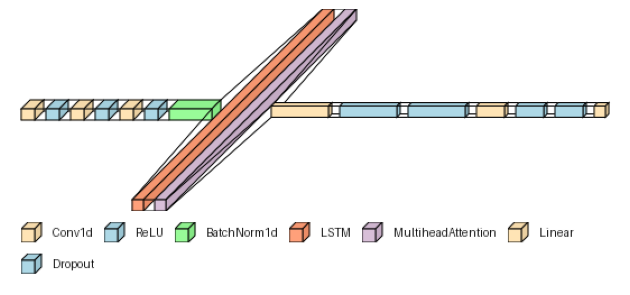

In [9]:
input_shape = (1, 24,14)

img = visualtorch.layered_view(model, input_shape=input_shape,legend=True)

plt.axis("off")
plt.tight_layout()
plt.imshow(img)
plt.show()
